## Fred Garcia (fbg2107)
Homework Assignment 2: Profiling Small LLM Workloads

- let's start by getting the system info


In [1]:
import torch
import psutil
import transformers
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    DataCollatorWithPadding,
)
from datasets import load_dataset
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import wandb
import numpy as np
import random
import platform


# gpu information
print(f"GPU : {torch.cuda.get_device_name(0)}")
gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU mem: {gpu_memory:.1f} GB")
# cpu information
print(f"CPU Model: {platform.processor()}")
print(
    f"CPU Cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical"
)
# pytorch and transformers versions
print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
# CUDA version (
print(f"CUDA version: {torch.version.cuda}")
# misc
print(f"Python Version: {platform.python_version()}")
print(f"system node RAM: {psutil.virtual_memory().total / (1024**3):.1f} GB")

/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' a

GPU : NVIDIA A100-SXM4-80GB
GPU mem: 85.2 GB
CPU Model: x86_64
CPU Cores: 64 physical, 64 logical
PyTorch Version: 2.9.0+cu128
Transformers Version: 4.57.1
CUDA version: 12.8
Python Version: 3.10.4
system node RAM: 1007.6 GB


In [2]:
# # get the wandb going
# wandb.init(project="hpml-hw2-llm")

# wandb.config.update(
#     {
#         "model_name": "distilbert-base-uncased",
#         "max_len": 256,
#         "batch_size": 32,
#         "lr": 1e-4,
#         "optimizer": "AdamW",
#         "num_workers": 2,
#         "epochs": 5,
#         "compile_mode": False,
#     }
# )

In [3]:
# set seeds
seed = 144
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

load data and inspect

In [4]:
dataset = load_dataset("imdb")

In [5]:
print(f"train samples: {len(dataset['train'])}")
print(f"test samples: {len(dataset['test'])}")

# we can print the text in some training set
test_index = 144
print(f"sample review: {dataset['train'][144]['text'][:]}...")
print(f"label: {dataset['train'][144]['label']}")

train samples: 25000
test samples: 25000
sample review: I won't say this movie was bad, but it wasn't good either. I expected something good but I guess Hum Aapke Hain Kaun was much better than this. This was completely old fashioned. At every stage of this movie, I hoped for some twist and what do I get? The girl gets burned and wins her aunt's love. <br /><br />Despite of being engaged, they have to take permission for every little move they make. They are so darn shy even after so many meetings. I expected the aunt to be much more brutal than that. All she did was crib madly. <br /><br />Hey, we have kids too, but we don't watch them and have tears in our eyes always. This movie is a dream. Happy family, one cruel woman, good in-laws and a man who loves her to death. In HAHK Anupam Kher was the poor bride's father and now it's vice versa. And I somehow knew that Mohnish Behl would be in this movie. Anyway I believe I wasted my time. I give it a 2/10....
label: 0


ok it looks like we are looking at text and seeing if the movie is good or not (0 for bad, 1 for good)


the rest of the section for __Dataset and Model__




In [6]:
model_name = "distilbert-base-uncased"

# tokenaize
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# move model to device with CUDA synchronization capability
device = torch.device("cuda")
model = model.to(device)

In [8]:
# we were told to use fixed sequence length so text will get truncated with this
MAX_LENGTH = 256
EPOCHS = 5

## C1

tokenzation (fixed length)

In [9]:
# we tocanize in this cell
# - sets truncation to true to cut off long reviews


def tokenize_function(examples):
    """tokenize with fixed max length , no padding (dynamic padding in collate_fn)"""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,  # dynamic padding handled in collate_fn
        max_length=MAX_LENGTH,  # fixed length for comparisons
        return_tensors=None,
    )


# we defined a function just for clarity, and apply his
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# remove text column and set format-- the words now will be turned into input_ids and attention_mask
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

In [10]:
# use Hugging Face's built-in collator for dynamic padding
# pad to longest sequence in batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",  # pad to longest sequence in batch
    return_tensors="pt",  # return PyTorch tensors
)

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    batch_size=32,
    shuffle=True,
    collate_fn=data_collator,
    num_workers=2,  # can use >0 since DataCollator is picklable
)

test_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=32,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=2,
)


print(f"train batches: {len(train_dataloader)}, test batches: {len(test_dataloader)}")
sample_batch = next(iter(train_dataloader))
print(
    f"sample batch - input_ids: {sample_batch['input_ids'].shape}, attention_mask: {sample_batch['attention_mask'].shape}"
)

train batches: 782, test batches: 782
sample batch - input_ids: torch.Size([32, 256]), attention_mask: torch.Size([32, 256])


In [ ]:
#######
wandb_config = {
    "model_name": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 32,
    "lr": 1e-4,
    "optimizer": "AdamW",
    "num_workers": 2,
    "epochs": EPOCHS,
    "component": "C1_baseline",
}

# create meaningful run name and group
run_name = f"bs_{wandb_config['batch_size']}_lr_{wandb_config['lr']}"
group_name = "C1_fine_tuning"

wandb.init(project="hpml-hw2-llm", name=run_name, group=group_name, config=wandb_config)
########

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_losses = []
train_accuracies = []
test_accuracies = []


def compute_accuracy(logits, labels):
    """compute accuracy given logits and true labels"""
    predictions = torch.argmax(logits, dim=-1)
    return (predictions == labels).float().mean()


for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    # training
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    train_batches = 0

    for batch in tqdm(train_dataloader, desc="training"):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(logits, batch["labels"])
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        train_batches += 1

    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches

    # evaluation
    model.eval()
    total_test_acc = 0
    test_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Testing"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            acc = compute_accuracy(outputs.logits, batch["labels"])
            total_test_acc += acc.item()
            test_batches += 1

    avg_test_acc = total_test_acc / test_batches

    # store metrics needed
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    test_accuracies.append(avg_test_acc)

    # log to W&B
    wandb.log(
        {
            "train/loss": avg_train_loss,
            "train/accuracy": avg_train_acc,
            "test/accuracy": avg_test_acc,
            "epoch": epoch + 1,
        }
    )

    print(
        f"train Loss: {avg_train_loss:.4f}, train Acc: {avg_train_acc:.4f}, test Acc: {avg_test_acc:.4f}"
    )

wandb: Currently logged in as: fgarcia4 (fgarcia4-columbia-uni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.08it/s]


train Loss: 0.3084, train Acc: 0.8691, test Acc: 0.9009
Epoch 2/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.05it/s]


...

train Loss: 0.0849, train Acc: 0.9710, test Acc: 0.8723
Epoch 4/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.19it/s]


train Loss: 0.0541, train Acc: 0.9820, test Acc: 0.8718
Epoch 5/5


Testing: 100%|██████████| 782/782 [00:42<00:00, 18.21it/s]

train Loss: 0.0393, train Acc: 0.9865, test Acc: 0.8465


### Figure F1

/tmp/ipykernel_2372012/1785005259.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


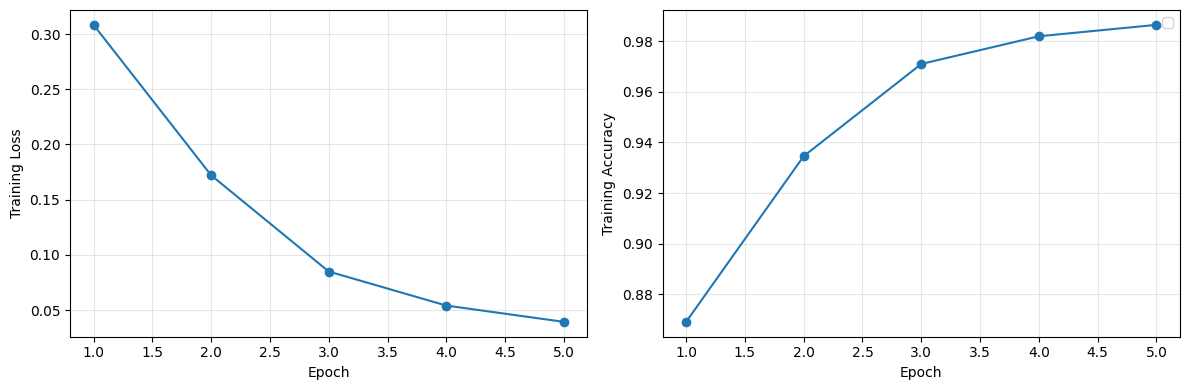

In [20]:
# This creates Figure F1
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Training loss decreasing over epochs
ax[0].plot(range(1, 6), train_losses, marker="o")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training Loss")
ax[0].grid(True, alpha=0.3)

# Right plot: Training and test accuracy increasing over epochs
ax[1].plot(range(1, 6), train_accuracies, marker="o")
# ax[1].plot(range(1, 6), test_accuracies, marker="s", label="test accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Training Accuracy")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./C1_F1.png", dpi=300, bbox_inches="tight")
plt.show()

### Table T1

In [22]:
table_t1 = pd.DataFrame(
    {
        "Epoch": range(1, 6),
        "Train Loss": [f"{loss:.4f}" for loss in train_losses],
        "Train Accuracy": [f"{acc:.4f}" for acc in train_accuracies],
        "Test Accuracy": [f"{acc:.4f}" for acc in test_accuracies],
    }
)
table_t1

,Epoch,Train Loss,Train Accuracy,Test Accuracy
0,1,0.3084,0.8691,0.9009
1,2,0.1721,0.9346,0.8804
2,3,0.0849,0.9710,0.8723
3,4,0.0541,0.9820,0.8718
4,5,0.0393,0.9865,0.8465
